Para esta notebook se usan los Datos Históricos de **Caudal Medio Diario de la Estacion 3805 - Paraná - Corrientes**

**Fuente de los datos:** Sistema Nacional de Información Hídrica (SNIH), Subsecretaría de Recursos Hídricos de la Nación, plataforma pública que centraliza información recopilada por la Red Hidrológica Nacional (RHN) y por otras redes de monitoreo hidrológico y meteorológico de la Argentina.

https://snih.hidricosargentina.gob.ar

Contiene información correspondiente a diferentes variables hidrológicas y meteorológicas, incluyendo niveles y caudales de ríos, precipitaciones, temperatura, humedad, evaporación y velocidad del viento, entre otras.

## **1.   Carga de datos**



Para cargar y leer los datos de un archivo de **excel** existen tres alternativas:

**1. Upload:** subir el archivo directamente desde la computadora.
  

In [ ]:
from google.colab import files

archivo = files.upload()

In [ ]:
import pandas as pd

datos = pd.read_excel("DatosHistoricos-Estacion3805.xlsx")

**2. Google Drive:** utilizar un archivo almacenado en Drive.



In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
#ruta = "/content/drive/MyDrive/SeriesTemporales/DatosHistoricos-Estacion3805.xlsx"

#datos = pd.read_excel(ruta)

**3. GitHub:** descargar el archivo desde un repositorio.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/DatosHistoricos-Estacion3805.xlsx"

datos = pd.read_excel(url)

datos.head()                # Permite observar las primeras 5 filas

,Datos Históricos - Estacion 3805 - Paraná - Corrientes,Unnamed: 1
0,Fecha y Hora,Caudal Medio Diario [m3/seg]
1,01/01/1904 07:43,15976.6
2,02/01/1904 07:43,16786.6
3,03/01/1904 07:43,17693.9
4,04/01/1904 07:43,18256.4


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 2 columns):
 #   Column                                                  Non-Null Count  Dtype 
---  ------                                                  --------------  ----- 
 0   Datos Históricos - Estacion 3805 - Paraná - Corrientes  44424 non-null  object
 1   Unnamed: 1                                              44424 non-null  object
dtypes: object(2)
memory usage: 694.3+ KB


In [ ]:
datos = pd.read_excel(url, header = 1)  # Importa el excel pero eliminando la primera fila

datos.head(6)                           # Permite observar las 6 primeras filas

# Con .tail() veo las últimas filas, si no indico cuántas se ven las últimas 5

,Fecha y Hora,Caudal Medio Diario [m3/seg]
0,01/01/1904 07:43,15976.6
1,02/01/1904 07:43,16786.6
2,03/01/1904 07:43,17693.9
3,04/01/1904 07:43,18256.4
4,05/01/1904 07:43,18908.7
5,06/01/1904 07:43,19571.1


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44423 entries, 0 to 44422
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Fecha y Hora                  44423 non-null  object 
 1   Caudal Medio Diario [m3/seg]  44423 non-null  float64
dtypes: float64(1), object(1)
memory usage: 694.2+ KB


## **2. Pre-Procesamiento de datos**

In [ ]:
datos.shape              # (Número de observaciones, Número de variables)

(44423, 2)

In [ ]:
datos.columns            # Nombres de las columnas

Index(['Fecha y Hora', 'Caudal Medio Diario [m3/seg]'], dtype='object')

In [ ]:
datos.dtypes

,0
Fecha y Hora,object
Caudal Medio Diario [m3/seg],float64


In [ ]:
datos["Fecha y Hora"] = pd.to_datetime(datos["Fecha y Hora"],
                                       dayfirst = True) # Avisa que el dato tiene formato dia/mes/año

datos.dtypes

,0
Fecha y Hora,datetime64[ns]
Caudal Medio Diario [m3/seg],float64


In [ ]:
datos.head()

,Fecha y Hora,Caudal Medio Diario [m3/seg]
0,1904-01-01 07:43:00,15976.6
1,1904-01-02 07:43:00,16786.6
2,1904-01-03 07:43:00,17693.9
3,1904-01-04 07:43:00,18256.4
4,1904-01-05 07:43:00,18908.7


In [ ]:
datos["Fecha y Hora"].dt.time.value_counts() # Cuenta cuántas veces las mediciones tuvieron el mismo horario exacto

,count
Fecha y Hora,
09:00:00,19755
08:00:00,7861
07:43:00,5965
00:00:00,5845
12:00:00,4261
10:00:00,736


In [ ]:
datos["Fecha y Hora"].dt.hour.value_counts()  # Cuenta cuántas veces las mediciones tuvieron la misma hora

,count
Fecha y Hora,
9,19755
8,7861
7,5965
0,5845
12,4261
10,736


In [ ]:
datos["Fecha y Hora"] = datos["Fecha y Hora"].dt.normalize()   # Cambia todos los horarios a medianoche
datos = datos.rename(columns={"Fecha y Hora": "Fecha"})        # Cambio el nombre a la columna
datos.head()

,Fecha,Caudal Medio Diario [m3/seg]
0,1904-01-01,15976.6
1,1904-01-02,16786.6
2,1904-01-03,17693.9
3,1904-01-04,18256.4
4,1904-01-05,18908.7


In [ ]:
datos["Caudal Alto"] = datos["Caudal Medio Diario [m3/seg]"] > 18000    # Agrego una columna nueva
datos.head()

,Fecha,Caudal Medio Diario [m3/seg],Caudal Alto
0,1904-01-01,15976.6,False
1,1904-01-02,16786.6,False
2,1904-01-03,17693.9,False
3,1904-01-04,18256.4,True
4,1904-01-05,18908.7,True


In [ ]:
datos = datos.drop(columns = ["Caudal Alto"])    # Elimino la columna 'Caudal Alto'
datos.head()

,Fecha,Caudal Medio Diario [m3/seg]
0,1904-01-01,15976.6
1,1904-01-02,16786.6
2,1904-01-03,17693.9
3,1904-01-04,18256.4
4,1904-01-05,18908.7


## **3. Acceso a los datos**



Se puede acceder a los valores de las columnas usando su nombre

In [ ]:
datos["Caudal Medio Diario [m3/seg]"]

,Caudal Medio Diario [m3/seg]
0,15976.60
1,16786.60
2,17693.90
3,18256.40
4,18908.70
...,...
44418,10765.54
44419,10792.24
44420,10946.36
44421,11364.67


O utilizando la función **.iloc** y su número de columna

In [ ]:
datos.iloc[:, 1]                      # Accede a la columna 2

,Caudal Medio Diario [m3/seg]
0,15976.60
1,16786.60
2,17693.90
3,18256.40
4,18908.70
...,...
44418,10765.54
44419,10792.24
44420,10946.36
44421,11364.67


Para acceder a las filas tenemos **.head()**, **.tail()** e **.iloc**

In [ ]:
datos.iloc[3]                        # Accede a la fila 3

,3
Fecha,1904-01-04 00:00:00
Caudal Medio Diario [m3/seg],18256.4


In [ ]:
datos.iloc[3:6]                     # Accede a las filas desde la 3 a la 6

,Fecha,Caudal Medio Diario [m3/seg]
3,1904-01-04,18256.4
4,1904-01-05,18908.7
5,1904-01-06,19571.1


Se puede acceder a las filas que corresponden a un rango de fechas de interés

In [ ]:
datos[datos["Fecha"] >= "2000-01-01"]

,Fecha,Caudal Medio Diario [m3/seg]
35047,2000-01-01,10877.20
35048,2000-01-02,10785.56
35049,2000-01-03,10361.63
35050,2000-01-04,9922.25
35051,2000-01-05,9829.36
...,...,...
44418,2025-08-27,10765.54
44419,2025-08-28,10792.24
44420,2025-08-29,10946.36
44421,2025-08-30,11364.67


In [ ]:
datos[(datos["Fecha"] >= "2000-01-01") &
      (datos["Fecha"] <  "2000-01-05")]

,Fecha,Caudal Medio Diario [m3/seg]
35047,2000-01-01,10877.20
35048,2000-01-02,10785.56
35049,2000-01-03,10361.63
35050,2000-01-04,9922.25


## **4. Análisis de los datos**


1) Se puede chequear si algún dato no está completo

In [ ]:
datos.isna().sum()

,0
Fecha,0
Caudal Medio Diario [m3/seg],0


2) Chequear cuántas fechas están duplicadas

In [ ]:
datos["Fecha"].duplicated().sum()

np.int64(1)

In [ ]:
datos[datos["Fecha"].duplicated(keep=False)]                    # Otras opciones para keep son 'first', 'last'

,Fecha,Caudal Medio Diario [m3/seg]
38577,2009-08-31,17068.09
38578,2009-08-31,17068.08


3) Puedo eliminar los datos de fechas duplicadas

In [ ]:
datos = datos.drop_duplicates(subset = "Fecha", keep = "first")   # Usando 'last' me quedo con la segunda, con False se eliminan ambos

Otra opción es eliminar la fila usando su número de fila:


In [ ]:
#datos = datos.drop(index = 38578).reset_index(drop=True) # Elimina la fila 38578

4) Chequear que hay información de todas las fechas

In [ ]:
fechas_esperadas = pd.date_range(start = datos["Fecha"].min(),
                                 end = datos["Fecha"].max(),
                                 freq = "D")
fechas_esperadas

DatetimeIndex(['1904-01-01', '1904-01-02', '1904-01-03', '1904-01-04',
               '1904-01-05', '1904-01-06', '1904-01-07', '1904-01-08',
               '1904-01-09', '1904-01-10',
               ...
               '2025-08-22', '2025-08-23', '2025-08-24', '2025-08-25',
               '2025-08-26', '2025-08-27', '2025-08-28', '2025-08-29',
               '2025-08-30', '2025-08-31'],
              dtype='datetime64[ns]', length=44439, freq='D')

In [ ]:
fechas_faltantes = fechas_esperadas.difference(datos["Fecha"]) # Compara fechas_esperadas con la columna 'Fecha' del dataset

print("Cantidad de fechas faltantes:", len(fechas_faltantes))

Cantidad de fechas faltantes: 17


In [ ]:
fechas_faltantes

DatetimeIndex(['1984-11-17', '1984-11-18', '1984-11-19', '1984-11-20',
               '1984-11-21', '1984-11-22', '1984-11-30', '1986-01-24',
               '1987-02-21', '1987-02-22', '1987-02-23', '1987-02-24',
               '1987-02-25', '1987-02-26', '1987-02-27', '1988-12-17',
               '1988-12-18'],
              dtype='datetime64[ns]', freq=None)

Otra forma podría ser con **.diff** que calcula la distancia entre datos consecutivos

In [ ]:
frecuencia = datos["Fecha"].diff().value_counts() # Usando value_counts() calcula cuantas veces hay cada intervalo de tiempo
frecuencia

,count
Fecha,
1 days,44416
2 days,2
7 days,1
8 days,1
3 days,1


5) Puedo agregar las filas de las fechas que no tengo en el dataset

In [ ]:
datos_completo = (datos.set_index("Fecha")         # Usa temporalmente Fecha como índice
                      .reindex(fechas_esperadas)   # Reemplaza el índice por fechas_esperadas
                      .rename_axis("Fecha")        # Asigna el nombre "Fecha" al nuevo índice
                      .reset_index())              # Convierte nuevamente el índice Fecha en una columna

In [ ]:
fechas_faltantes.isin(datos_completo["Fecha"]) # Puedo chequear que todas las fechas faltantes estén ahora en la columna fechas del nuevo dataset

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True])

In [ ]:
nuevas_fechas_faltantes = fechas_esperadas.difference(datos_completo["Fecha"])

print("Cantidad de fechas faltantes:", len(nuevas_fechas_faltantes))

Cantidad de fechas faltantes: 0


Las fechas agregadas van a tener valores nulos en la otra columna



In [ ]:
datos_completo.isna().sum()

,0
Fecha,0
Caudal Medio Diario [m3/seg],17


Puedo visualizar las filas que no tienen contenido en la columna "Caudal Medio Diario"

In [ ]:
datos_completo[datos_completo["Caudal Medio Diario [m3/seg]"].isna()]

,Fecha,Caudal Medio Diario [m3/seg]
29541,1984-11-17,NaN
29542,1984-11-18,NaN
29543,1984-11-19,NaN
29544,1984-11-20,NaN
29545,1984-11-21,NaN
29546,1984-11-22,NaN
29554,1984-11-30,NaN
29974,1986-01-24,NaN
30367,1987-02-21,NaN
30368,1987-02-22,NaN


In [ ]:
datos_completo.isna().any(axis=1).sum() # Cantidad de filas con algún dato faltante

np.int64(17)

6) Los datos faltantes se pueden rellenar:
* Con 0 usando **fillna(0)** (o con cualquier otro número)

In [ ]:
datos_filled = datos_completo["Caudal Medio Diario [m3/seg]"].fillna(0)
datos_filled.iloc[29541]

np.float64(0.0)

* Con infinito usando **fillna(np.inf)**

In [ ]:
import numpy as np
datos_filled = datos_completo["Caudal Medio Diario [m3/seg]"].fillna(np.inf)
datos_filled.iloc[29541]

np.float64(inf)

* Con el último valor usando **ffill()**

In [ ]:
datos_filled = datos_completo["Caudal Medio Diario [m3/seg]"].ffill()
datos_filled.iloc[29541]

np.float64(20649.8)

In [ ]:
datos_filled.iloc[29540]

np.float64(20649.8)

* Con un valor obtenido por interpolación lineal de los valores vecinos usando **interpolate()**

In [ ]:
datos_filled = datos_completo["Caudal Medio Diario [m3/seg]"].interpolate()
datos_filled.iloc[29541]

np.float64(20663.371428571427)

In [ ]:
(datos_filled.iloc[29540]  +  datos_filled.iloc[29542] ) /2

np.float64(20663.37142857143)

7) Los datos se pueden ordenar según el valor de la columna que se quiera

In [ ]:
# Ordenar por Caudal Medio
datos = datos.sort_values("Caudal Medio Diario [m3/seg]")
datos.head()

,Fecha,Caudal Medio Diario [m3/seg]
14890,1944-10-07,3945.6
14889,1944-10-06,3966.3
14891,1944-10-08,3966.3
14888,1944-10-05,3987.0
14886,1944-10-03,4007.7


In [ ]:
# Ordenar por Fecha
datos = datos.sort_values("Fecha")
datos.head()

,Fecha,Caudal Medio Diario [m3/seg]
0,1904-01-01,15976.6
1,1904-01-02,16786.6
2,1904-01-03,17693.9
3,1904-01-04,18256.4
4,1904-01-05,18908.7


8) Se puede analizar más en detalle el contenido de cada columna

In [ ]:
datos["Caudal Medio Diario [m3/seg]"].describe()

,Caudal Medio Diario [m3/seg]
count,44422.000000
mean,17122.382995
std,6322.008323
min,3945.600000
25%,12810.400000
50%,16240.270000
75%,20424.557500
max,60215.000000


In [ ]:
datos["Caudal Medio Diario [m3/seg]"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,Caudal Medio Diario [m3/seg]
0.01,6573.0000
0.05,8373.2440
0.25,12810.4000
0.50,16240.2700
0.75,20424.5575
0.95,28410.2000
0.99,36757.5057


## **5. Visualización de Datos**

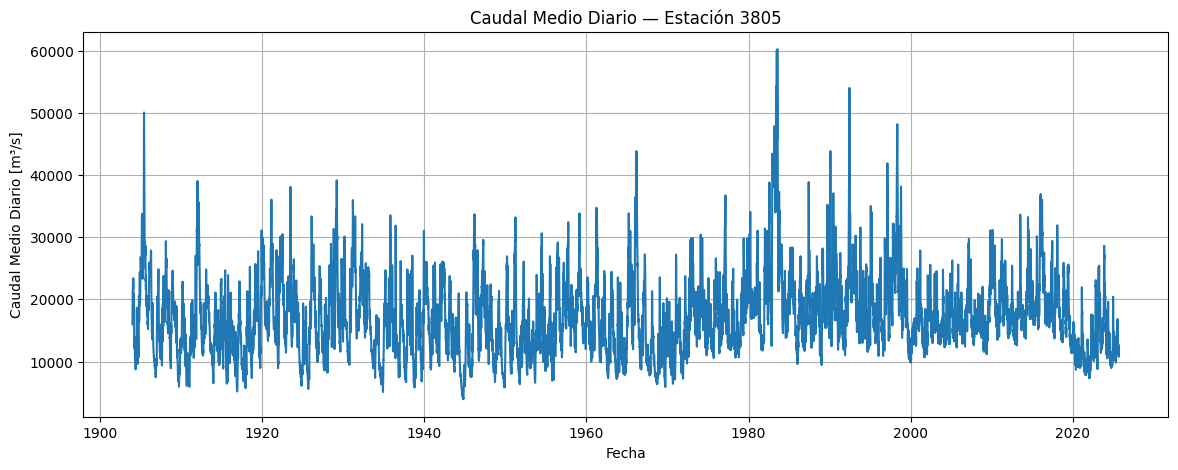

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(datos["Fecha"], datos["Caudal Medio Diario [m3/seg]"])

plt.xlabel("Fecha")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Caudal Medio Diario — Estación 3805")
plt.grid()
plt.show()

In [ ]:
datos["Mes"] = datos["Fecha"].dt.month  # Agrego una columna que indique únicamente el mes, extrayendo la información de la fecha
# Podria extraer 'year', 'day', 'hour', 'minute', 'dayofweek'

caudal_mensual = datos.groupby("Mes")["Caudal Medio Diario [m3/seg]"].mean()    # Agrupa los datos por mes y calcula la media de los valores en la columna 'Caudal Medio Diario'

caudal_mensual

,Caudal Medio Diario [m3/seg]
Mes,
1,18422.786638
2,20826.641151
3,20620.182422
4,19142.820298
5,17658.709646
6,17861.524525
7,16271.404762
8,13860.609347
9,13431.487601


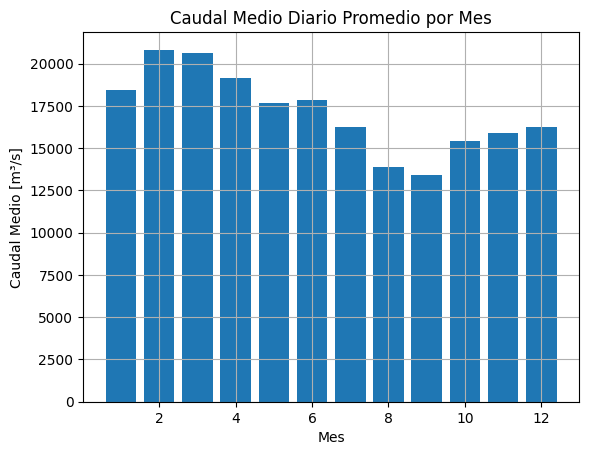

In [ ]:
plt.bar(caudal_mensual.index, caudal_mensual.values)
plt.xlabel("Mes")
plt.ylabel("Caudal Medio [m³/s]")
plt.title("Caudal Medio Diario Promedio por Mes")
plt.grid()
plt.show()

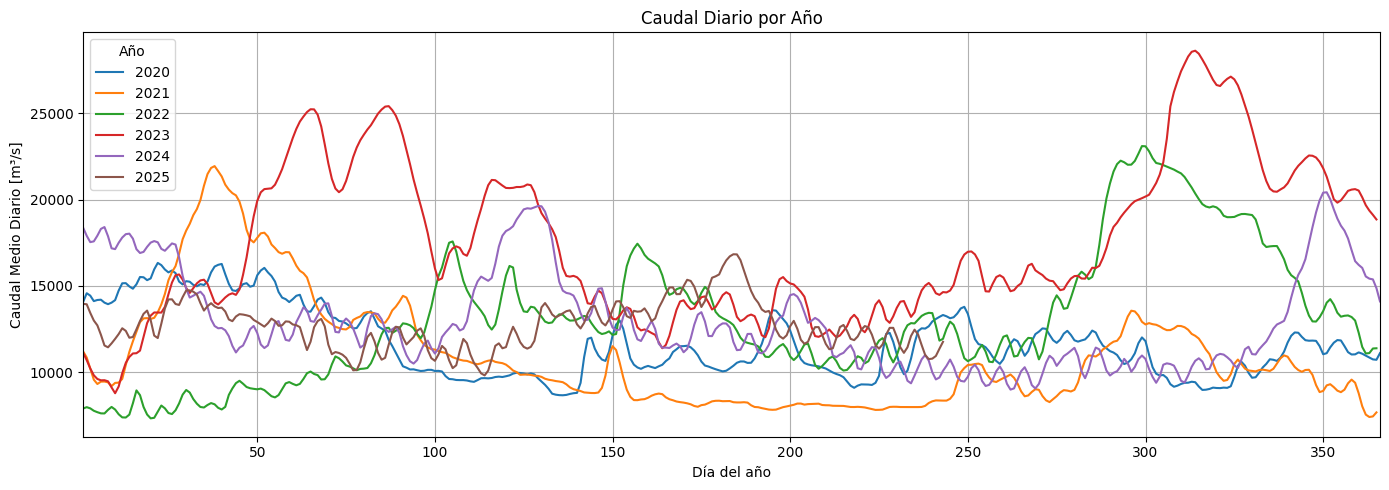

In [ ]:
desde2020 = datos[(datos["Fecha"] >= "2020-01-01")].copy()  # Sirve para hacer una copia de una porción del dataset que nos interesa

plt.figure(figsize=(14, 5))

for año, grupo in datos.groupby(desde2020["Fecha"].dt.year): # groupby agrupa los datos, en este caso por año
    plt.plot(grupo["Fecha"].dt.dayofyear,
            grupo["Caudal Medio Diario [m3/seg]"],
            label = int(año))

plt.xlabel("Día del año")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Caudal Diario por Año")
plt.xlim(1, 366)
plt.grid(True)
plt.legend(title="Año", loc="upper left")
plt.tight_layout()
plt.show()

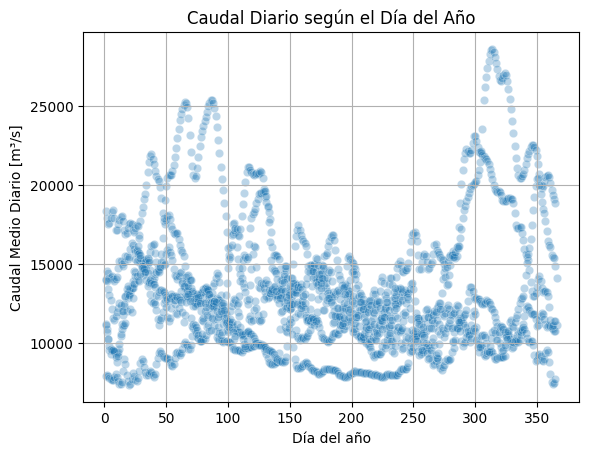

In [ ]:
import seaborn as sns

desde2020["Día"] = desde2020["Fecha"].dt.dayofyear # Crea columna dia

sns.scatterplot(
    data = desde2020,
    x = "Día",
    y = "Caudal Medio Diario [m3/seg]",
    alpha = 0.3)

plt.xlabel("Día del año")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Caudal Diario según el Día del Año")
plt.grid()
plt.show()

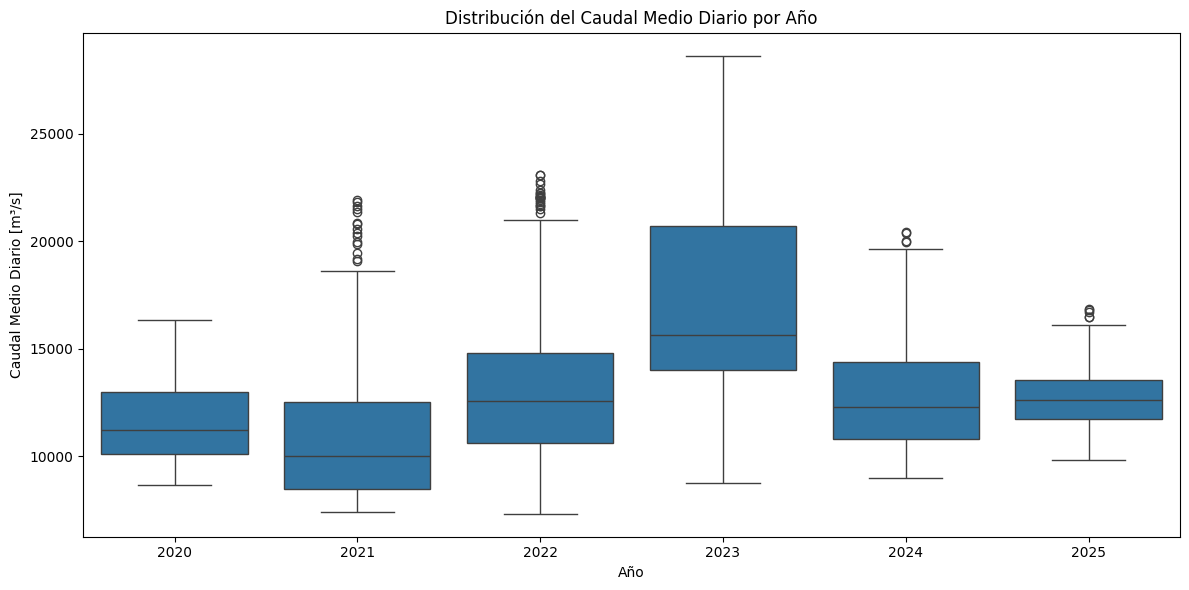

In [ ]:
desde2020["Año"] = desde2020["Fecha"].dt.year        # Crea columna año

plt.figure(figsize=(12, 6))

sns.boxplot(
    data = desde2020,
    x = "Año",
    y = "Caudal Medio Diario [m3/seg]"
)

plt.xlabel("Año")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Distribución del Caudal Medio Diario por Año")

plt.tight_layout()
plt.show();

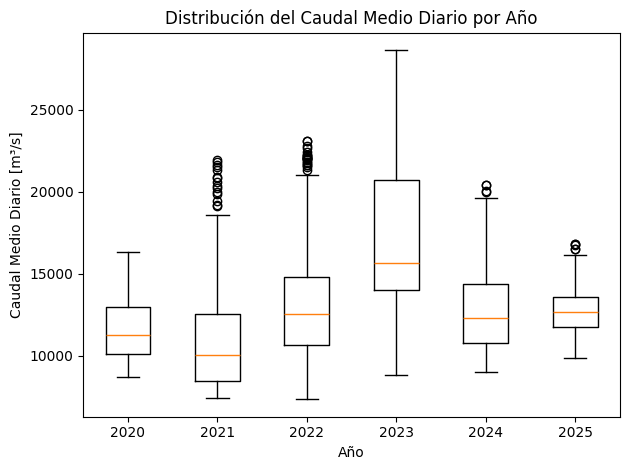

In [ ]:
grupos = desde2020.groupby("Año")["Caudal Medio Diario [m3/seg]"] # groupby agrupa los datos, en este caso por año

datos_box = [grupo for _, grupo in grupos]

plt.boxplot(datos_box,
            tick_labels = sorted(desde2020["Año"].unique()))

plt.xlabel("Año")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Distribución del Caudal Medio Diario por Año")

plt.tight_layout()
plt.show();

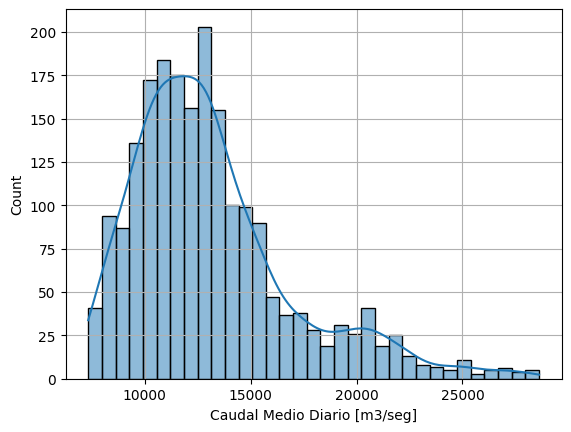

In [ ]:
sns.histplot(data = desde2020, x = "Caudal Medio Diario [m3/seg]", kde = True)
plt.grid();


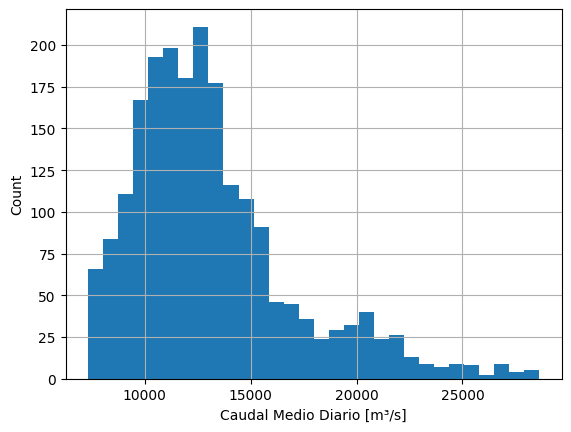

In [ ]:
plt.hist(desde2020["Caudal Medio Diario [m3/seg]"], bins = 30)
plt.ylabel("Count")
plt.xlabel("Caudal Medio Diario [m³/s]")
plt.grid();

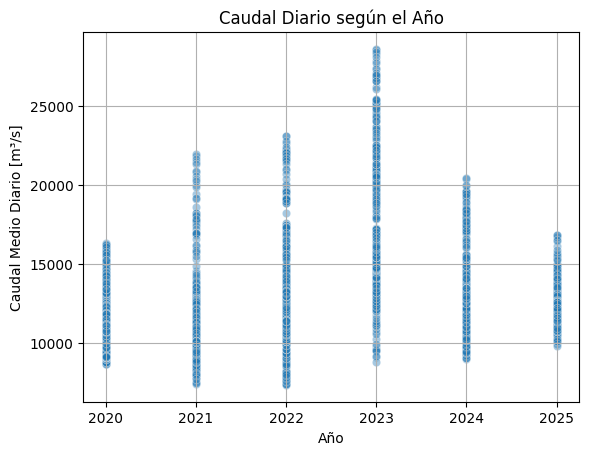

In [ ]:
sns.scatterplot(
    data = desde2020,
    x = "Año",
    y = "Caudal Medio Diario [m3/seg]",
    alpha = 0.4)

plt.xlabel("Año")
plt.ylabel("Caudal Medio Diario [m³/s]")
plt.title("Caudal Diario según el Año")
plt.grid()
plt.show()